# 07. The Bayesian model as an operational forecaster

**Goal.** Notebooks 03 to 06 scored the Bayesian AR(1) + GP model. This one
runs it the way a control-room would: pick a real high-demand winter
evening, forecast it, re-forecast it as the event approaches, and read off
the operational risk metrics that matter, all from one generative model.
Every panel here is a functional of the joint predictive (a peak, a ramp, a
threshold exceedance, a stress duration), which only a model that samples
coherent whole-day trajectories can produce.

The model is fitted once by full-rank ADVI on the contiguous training
series, so it forecasts from any origin (notebook 06). Here it is issued
repeatedly: a sequence of forecasts for the same target, each conditioning
on demand observed up to its issue time and on a weather forecast whose
error shrinks as the event nears. The story is how the forecast and its
risk numbers sharpen across those updates.

In [1]:
import os

os.environ.setdefault("JAX_PLATFORMS", "cpu")

from dataclasses import replace

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Circle

from nemforecastdemand.config import load_config
from nemforecastdemand.data.loaders import load_panel, load_splits
from nemforecastdemand.features.weather import degree_days
from nemforecastdemand.models import bsts, innovations
from nemforecastdemand.models.base import build_design, perturbation_overrides, variance_design
from nemforecastdemand.models.predict import fit_perturbation_models
from nemforecastdemand.plotting import palette, save_figure, setup_style
from nemforecastdemand.splits import horizon_index
from nemforecastdemand.utils import load_artifact

setup_style()
cfg = load_config()
GP_TIME_HARMONICS, GP_TEMP_BASIS = 6, 8
cfg_gp = replace(
    cfg,
    features=replace(
        cfg.features, hsgp_time_harmonics=GP_TIME_HARMONICS, hsgp_temp_basis=GP_TEMP_BASIS
    ),
)

panel = load_panel(cfg.paths.processed)
splits = load_splits(cfg.paths.processed)
fit_index = splits["train"].index[max(cfg.features.demand_lags) :]
inputs = bsts.prepare_inputs(panel, cfg_gp, fit_index)
gp = load_artifact(cfg.paths.artifacts / "bsts_hsgp_vi_fullrank")[0]
draws = {name: gp[f"draw_{name}"] for name in ("rho", "beta", "gamma0", "gamma")}
perturbations = fit_perturbation_models(panel, splits["train"].index)

LOCAL = "Australia/Brisbane"  # AEST, no daylight saving, the market clock
BLUE = palette("demand")
ALERT = {"green": "#2e7d32", "amber": "#f9a825", "red": "#c62828"}

/home/s95717/miniforge3/envs/nem-demand-forecast/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## The target and the issue schedule

The target is the evening peak of 1 July 2025, a winter cold snap that
reached 13.1 GW, 95.6 percent of the highest demand seen anywhere in the
training history. The operator wants to know, in advance, how high the
evening will go and how likely it is to threaten the record. The spike
threshold is set as a fraction of that past observed maximum.

Forecasts are issued at 24, 18, 12, 6 and 3 hours before the nominal 18:00
peak, a realistic intraday re-forecast cadence. Each later issue has seen
more of the day unfold and is paired with a sharper weather forecast: the
day-ahead weather error (calibrated in notebook 05) is scaled down in
proportion to lead time, so the 3-hour forecast is run on near-perfect
weather and the 24-hour forecast on the full day-ahead error.

In [2]:
TARGET_DATE = pd.Timestamp("2025-07-01").date()
PEAK_LOCAL = pd.Timestamp(f"{TARGET_DATE} 18:00", tz=LOCAL)
EVENING = (15, 21)  # local hours bounding the evening peak window
LEADS = [24, 18, 12, 6, 3]  # hours before the nominal peak
HERO_LEAD = 6  # the "current" operational forecast for the console view
THRESH_FRACTIONS = [0.85, 0.90, 0.95]

# Past observed maximum, strictly before the target day starts.
hist_max = float(panel["demand_mw"].loc[: (PEAK_LOCAL.normalize().tz_convert("UTC"))].iloc[:-1].max())
thresholds = {f: f * hist_max for f in THRESH_FRACTIONS}
window = panel.loc[
    PEAK_LOCAL.tz_convert("UTC") - pd.Timedelta(days=12) : PEAK_LOCAL.tz_convert("UTC")
    + pd.Timedelta(days=2)
].copy()
print(f"target evening: {TARGET_DATE}, past observed maximum {hist_max:.0f} MW")
print("spike thresholds (MW):", {f: round(v) for f, v in thresholds.items()})


def vintage_paths(origin, multiplier, n_weather=10, seed0=0):
    """Predictive paths (S, 48) in MW from one issue time, pooling demand-model
    uncertainty over a small ensemble of weather forecasts whose error scales
    with lead. History uses realised weather; the horizon uses the forecast."""
    hist = window.index[
        (window.index >= inputs.index[0]) & (window.index <= origin + pd.Timedelta(hours=24))
    ]
    design = build_design(window, cfg_gp, "actual").loc[hist]
    vdesign = variance_design(window, cfg_gp, "actual").loc[hist]
    x_hist, _ = bsts.transform_design(inputs, design, vdesign)
    y_hist = ((window["demand_mw"].loc[hist].to_numpy() - inputs.y_loc) / inputs.y_scale).astype(
        np.float32
    )
    e0 = innovations.origin_residuals(draws, y_hist, x_hist, hist.get_indexer([origin]))
    target = horizon_index(origin, cfg.horizon)
    segments = []
    for k, group in enumerate(np.array_split(np.arange(e0.shape[0]), n_weather)):
        if multiplier > 0:
            overrides = perturbation_overrides(window, target, perturbations, multiplier, cfg.seed + seed0 + k)
            hblock = build_design(window, cfg_gp, "actual", overrides=overrides).loc[target]
            vblock = vdesign.loc[target].copy()
            deg = degree_days(overrides["temp_c"], cfg.weather.heating_base, cfg.weather.cooling_base)
            vblock[["cooling_deg", "heating_deg"]] = deg.to_numpy()
        else:
            hblock, vblock = design.loc[target], vdesign.loc[target]
        xf, zf = bsts.transform_design(inputs, hblock, vblock)
        block_draws = {name: value[group] for name, value in draws.items()}
        sim = innovations.simulate_horizon_paths(
            block_draws, e0[group], xf[None], zf[None], cfg_gp.bsts, seed=cfg.seed + seed0 * 97 + k
        )
        segments.append(np.asarray(sim[:, 0, :]))
    return np.concatenate(segments) * inputs.y_scale + inputs.y_loc, target


vintages = {}
for lead in LEADS:
    origin = (PEAK_LOCAL - pd.Timedelta(hours=lead)).tz_convert("UTC")
    paths, target = vintage_paths(origin, multiplier=lead / 24.0, seed0=lead)
    vintages[lead] = {"paths": paths, "target": target, "origin": origin}
    print(f"  issued {lead:2d}h ahead at {origin.tz_convert(LOCAL):%d %b %H:%M}: {paths.shape[0]} paths")


def evening_slice(target):
    """Boolean mask of the target-evening half hours within a horizon index."""
    local = target.tz_convert(LOCAL)
    same_day = np.array([t.date() == TARGET_DATE for t in local])
    return same_day & (local.hour >= EVENING[0]) & (local.hour <= EVENING[1])


def peak_draws(record):
    """Per-path maximum demand over the target evening, (S,)."""
    return record["paths"][:, evening_slice(record["target"])].max(axis=1)

target evening: 2025-07-01, past observed maximum 13716 MW
spike thresholds (MW): {0.85: 11658, 0.9: 12344, 0.95: 13030}


  issued 24h ahead at 30 Jun 18:00: 1000 paths


  issued 18h ahead at 01 Jul 00:00: 1000 paths


  issued 12h ahead at 01 Jul 06:00: 1000 paths


  issued  6h ahead at 01 Jul 12:00: 1000 paths


  issued  3h ahead at 01 Jul 15:00: 1000 paths


## The console: tonight's forecast

The current operational view, the forecast issued six hours before the
peak. The fan is the predictive density (50, 80 and 95 percent bands) with
the median; the dashed line is the spike threshold at 95 percent of the
past maximum and the red wash is the exceedance region. The panel on the
right is the readout an operator acts on: the forecast peak with its 90
percent interval, the probability of a spike, the expected number of stress
hours, the steepest expected ramp and an alert status driven by the spike
probability.

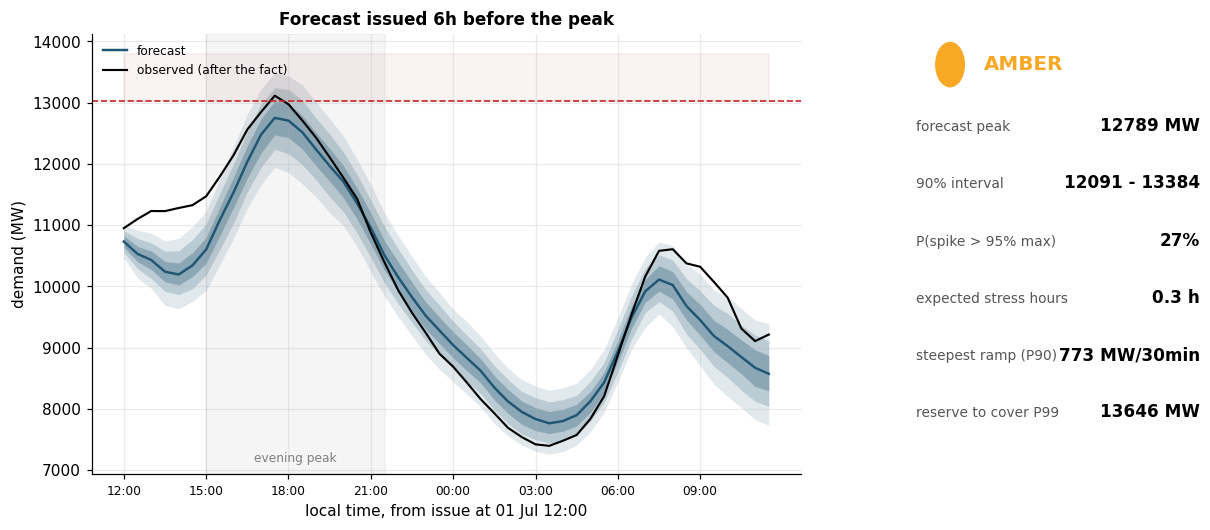

In [3]:
def fan(ax, x, paths, color, label=None):
    for lo, hi, alpha in [(0.025, 0.975, 0.13), (0.1, 0.9, 0.20), (0.25, 0.75, 0.30)]:
        ax.fill_between(x, np.quantile(paths, lo, 0), np.quantile(paths, hi, 0), color=color, alpha=alpha, lw=0)
    ax.plot(x, np.median(paths, 0), color=color, lw=1.6, label=label)


def alert_for(prob):
    return "red" if prob > 0.5 else "amber" if prob > 0.15 else "green"


hero = vintages[HERO_LEAD]
htarget = hero["target"]
hlocal = htarget.tz_convert(LOCAL)
hx = np.arange(cfg.horizon)
evening = evening_slice(htarget)
spike = thresholds[0.95]
pk = peak_draws(hero)
p_spike = float((pk > spike).mean())
stress_hours = (hero["paths"] > spike).sum(axis=1) * 0.5
ramp = np.diff(hero["paths"], axis=1).max(axis=1)
obs_hero = panel["demand_mw"].loc[htarget].to_numpy()

fig = plt.figure(figsize=(13, 5.2))
grid = fig.add_gridspec(1, 3, width_ratios=[2.5, 0.05, 1.0], wspace=0.15)
ax = fig.add_subplot(grid[0, 0])
fan(ax, hx, hero["paths"], BLUE, label="forecast")
ax.plot(hx, obs_hero, color="black", lw=1.4, label="observed (after the fact)")
ax.axhline(spike, color=ALERT["red"], ls="--", lw=1.1)
ax.fill_between(hx, spike, ax.get_ylim()[1], color=ALERT["red"], alpha=0.06)
ax.axvspan(np.where(evening)[0][0], np.where(evening)[0][-1], color="grey", alpha=0.08)
ax.text(np.where(evening)[0].mean(), ax.get_ylim()[0] + 200, "evening peak", ha="center", fontsize=8, color="grey")
tick = np.arange(0, cfg.horizon, 6)
ax.set_xticks(tick)
ax.set_xticklabels([f"{hlocal[t]:%H:%M}" for t in tick], fontsize=8)
ax.set_xlabel(f"local time, from issue at {hero['origin'].tz_convert(LOCAL):%d %b %H:%M}")
ax.set_ylabel("demand (MW)")
ax.set_title(f"Forecast issued {HERO_LEAD}h before the peak")
ax.legend(loc="upper left", fontsize=8)

panel_ax = fig.add_subplot(grid[0, 2])
panel_ax.axis("off")
status = alert_for(p_spike)
panel_ax.add_patch(Circle((0.12, 0.93), 0.05, color=ALERT[status], transform=panel_ax.transAxes))
panel_ax.text(0.24, 0.93, f"{status.upper()}", va="center", fontsize=13, weight="bold", color=ALERT[status], transform=panel_ax.transAxes)
lines = [
    ("forecast peak", f"{np.median(pk):.0f} MW"),
    ("90% interval", f"{np.quantile(pk, 0.05):.0f} - {np.quantile(pk, 0.95):.0f}"),
    (f"P(spike > {THRESH_FRACTIONS[-1]:.0%} max)", f"{p_spike:.0%}"),
    ("expected stress hours", f"{stress_hours.mean():.1f} h"),
    ("steepest ramp (P90)", f"{np.quantile(ramp, 0.9):.0f} MW/30min"),
    ("reserve to cover P99", f"{np.quantile(pk, 0.99):.0f} MW"),
]
for i, (k, v) in enumerate(lines):
    y = 0.78 - i * 0.13
    panel_ax.text(0.0, y, k, fontsize=9, color="#555", transform=panel_ax.transAxes)
    panel_ax.text(1.0, y, v, fontsize=11, weight="bold", ha="right", transform=panel_ax.transAxes)
save_figure(fig, "ops_console", cfg.paths.figures)
plt.show()

## How the forecast sharpens as the event nears

The same evening, forecast at each issue time. The left panel overlays the
median and 80 percent band of every vintage, coloured from the earliest
(palest) to the latest, against what actually happened. The right panel is
the same story as two numbers: the forecast peak (with its 10 to 90 percent
range) homing in on the realised peak as lead shrinks.

The honest lesson is in the early vintages. A day out, the model forecasts
an ordinary winter evening near 11 GW, because the seasonal and weather
terms have no reason to expect a record; it is only as the cold snap shows
up in the demand observed through the afternoon that the AR(1) error carries
the elevated level into the evening and the forecast climbs to meet the
peak. The predictive band is driven mainly by intrinsic demand volatility
rather than weather-forecast error here, so it tightens most in the final
hours as the AR anchor takes hold. This is exactly why operators re-forecast
intraday, and the probabilistic model makes the value of each update
explicit.

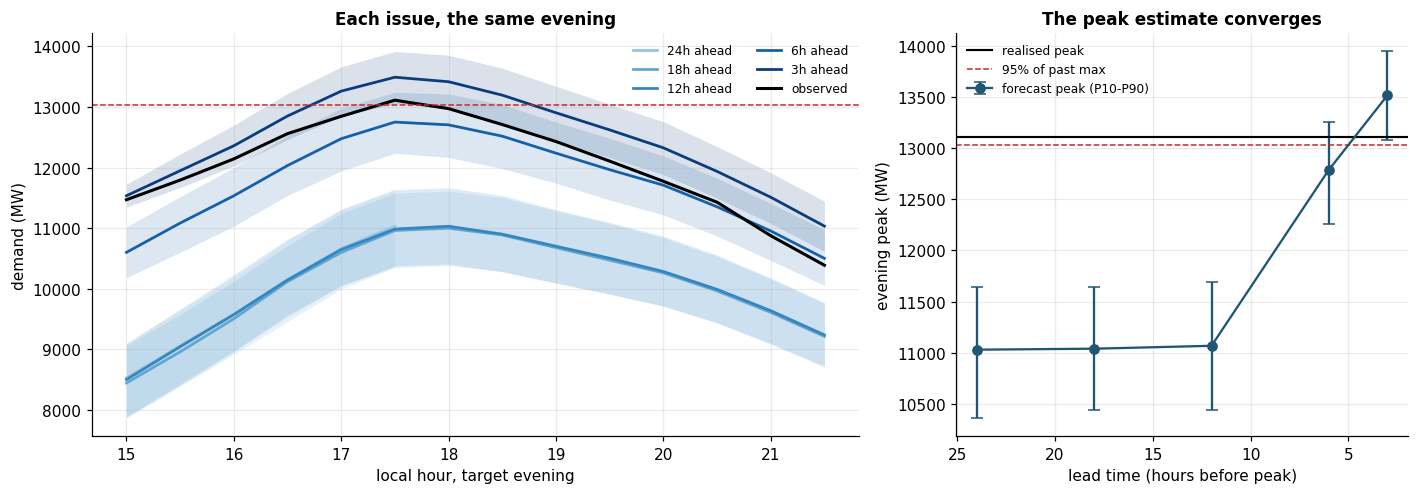

In [4]:
fig, (axf, axp) = plt.subplots(1, 2, figsize=(13, 4.6), gridspec_kw={"width_ratios": [1.7, 1.0]})
shades = plt.cm.Blues(np.linspace(0.4, 0.95, len(LEADS)))
ev_local = None
for colour, lead in zip(shades, LEADS, strict=True):
    rec = vintages[lead]
    mask = evening_slice(rec["target"])
    et = rec["target"][mask].tz_convert(LOCAL)
    ev_local = et
    ev_paths = rec["paths"][:, mask]
    hours = et.hour + et.minute / 60
    axf.fill_between(hours, np.quantile(ev_paths, 0.1, 0), np.quantile(ev_paths, 0.9, 0), color=colour, alpha=0.15, lw=0)
    axf.plot(hours, np.median(ev_paths, 0), color=colour, lw=1.8, label=f"{lead}h ahead")
obs_ev = panel["demand_mw"].loc[vintages[HERO_LEAD]["target"]][evening_slice(vintages[HERO_LEAD]["target"])]
axf.plot(ev_local.hour + ev_local.minute / 60, obs_ev.to_numpy(), color="black", lw=2.0, label="observed")
axf.axhline(spike, color=ALERT["red"], ls="--", lw=1.0)
axf.set_xlabel("local hour, target evening")
axf.set_ylabel("demand (MW)")
axf.set_title("Each issue, the same evening")
axf.legend(fontsize=8, ncol=2)

med = [np.median(peak_draws(vintages[lead])) for lead in LEADS]
lo = [np.quantile(peak_draws(vintages[lead]), 0.1) for lead in LEADS]
hi = [np.quantile(peak_draws(vintages[lead]), 0.9) for lead in LEADS]
axp.errorbar(LEADS, med, yerr=[np.array(med) - lo, np.array(hi) - med], fmt="o-", color=BLUE, capsize=4, label="forecast peak (P10-P90)")
axp.axhline(obs_ev.max(), color="black", lw=1.4, ls="-", label="realised peak")
axp.axhline(spike, color=ALERT["red"], ls="--", lw=1.0, label=f"{THRESH_FRACTIONS[-1]:.0%} of past max")
axp.set_xlabel("lead time (hours before peak)")
axp.set_ylabel("evening peak (MW)")
axp.set_title("The peak estimate converges")
axp.invert_xaxis()
axp.legend(fontsize=8)
fig.tight_layout()
save_figure(fig, "ops_forecast_evolution", cfg.paths.figures)
plt.show()

## Spike probability, and how it resolves

The metric a control-room cares about most: the probability that the
evening breaches a high-load threshold, tracked as the forecast updates.
Three thresholds, each a fraction of the past observed maximum. As lead
shrinks the probabilities resolve toward zero or one, and the background
shading is the alert status the operator would post, green to amber to red,
off the strictest threshold. A day out the model is relaxed; by the early
afternoon it is signalling a near-certain record approach, which is what
the evening delivered.

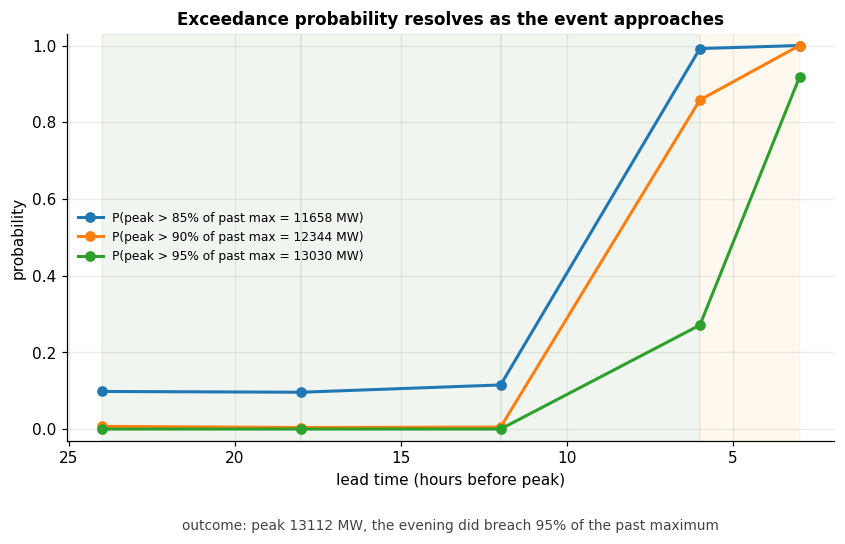

In [5]:
fig, ax = plt.subplots(figsize=(9, 4.8))
realised_peak = obs_ev.max()
for frac in THRESH_FRACTIONS:
    probs = [float((peak_draws(vintages[lead]) > thresholds[frac]).mean()) for lead in LEADS]
    ax.plot(LEADS, probs, "o-", lw=2, label=f"P(peak > {frac:.0%} of past max = {thresholds[frac]:.0f} MW)")
strict = [float((peak_draws(vintages[lead]) > thresholds[0.95]).mean()) for lead in LEADS]
for x0, x1, lead_prob in zip(LEADS[:-1], LEADS[1:], strict[:-1], strict=True):
    band = alert_for(lead_prob)
    ax.axvspan(min(x0, x1), max(x0, x1), color=ALERT[band], alpha=0.07)
ax.set_xlabel("lead time (hours before peak)")
ax.set_ylabel("probability")
ax.set_ylim(-0.03, 1.03)
ax.invert_xaxis()
ax.set_title("Exceedance probability resolves as the event approaches")
outcome = "the evening did breach 95% of the past maximum" if realised_peak > thresholds[0.95] else "the evening stayed below 95%"
ax.text(0.5, -0.22, f"outcome: peak {realised_peak:.0f} MW, {outcome}", transform=ax.transAxes, ha="center", fontsize=9, color="#444")
ax.legend(fontsize=8, loc="center left")
save_figure(fig, "ops_spike_probability", cfg.paths.figures)
plt.show()

## The operator's risk grid

Four functionals of the same coherent paths, from the six-hour forecast,
none of which a set of independent per-step quantiles could produce.

- **Peak timing and height together.** Not just how high but when, as a
  joint density; the operator schedules around both.
- **Steepest ramp.** The largest half-hour rise in the day, which sizes
  fast-start and regulation reserve, with the chance it clears a trigger.
- **Stress duration.** How many half hours sit above the threshold, the
  length of the exposure rather than just its peak.
- **Coherent scenarios.** A handful of whole-day trajectories to feed a
  downstream study (reserve, storage, power flow), each physically
  plausible rather than a jagged draw from per-step marginals.

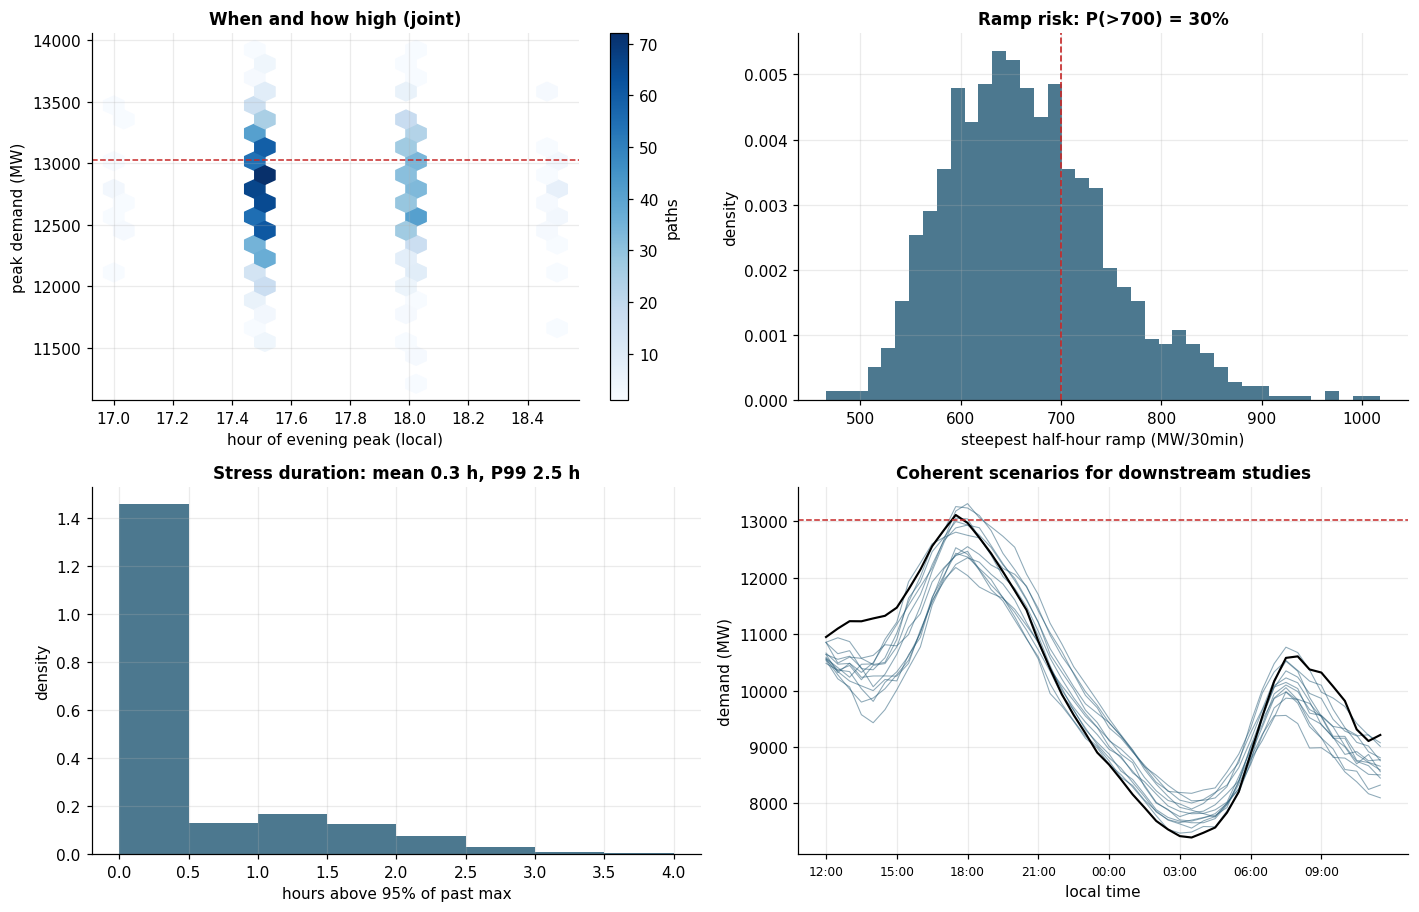

In [6]:
peak_step = hero["paths"][:, evening].argmax(axis=1)
peak_hour = (hlocal[evening].hour + hlocal[evening].minute / 60).to_numpy()[peak_step]
peak_mw = hero["paths"][:, evening].max(axis=1)
ramp_trigger = 700.0

fig, axes = plt.subplots(2, 2, figsize=(13, 8.4))
hb = axes[0, 0].hexbin(peak_hour, peak_mw, gridsize=22, cmap="Blues", mincnt=1)
axes[0, 0].axhline(spike, color=ALERT["red"], ls="--", lw=1.0)
axes[0, 0].set_xlabel("hour of evening peak (local)")
axes[0, 0].set_ylabel("peak demand (MW)")
axes[0, 0].set_title("When and how high (joint)")
fig.colorbar(hb, ax=axes[0, 0], label="paths")

axes[0, 1].hist(ramp, bins=40, color=BLUE, alpha=0.8, density=True)
axes[0, 1].axvline(ramp_trigger, color=ALERT["red"], ls="--", lw=1.1)
axes[0, 1].set_xlabel("steepest half-hour ramp (MW/30min)")
axes[0, 1].set_ylabel("density")
axes[0, 1].set_title(f"Ramp risk: P(>{ramp_trigger:.0f}) = {(ramp > ramp_trigger).mean():.0%}")

bins = np.arange(0, stress_hours.max() + 1.0, 0.5)
axes[1, 0].hist(stress_hours, bins=bins, color=BLUE, alpha=0.8, density=True)
axes[1, 0].set_xlabel(f"hours above {THRESH_FRACTIONS[-1]:.0%} of past max")
axes[1, 0].set_ylabel("density")
axes[1, 0].set_title(f"Stress duration: mean {stress_hours.mean():.1f} h, P99 {np.quantile(stress_hours, 0.99):.1f} h")

for s in range(12):
    axes[1, 1].plot(hx, hero["paths"][s], color=BLUE, lw=0.7, alpha=0.5)
axes[1, 1].plot(hx, obs_hero, color="black", lw=1.4)
axes[1, 1].axhline(spike, color=ALERT["red"], ls="--", lw=1.0)
axes[1, 1].set_xticks(tick)
axes[1, 1].set_xticklabels([f"{hlocal[t]:%H:%M}" for t in tick], fontsize=8)
axes[1, 1].set_xlabel("local time")
axes[1, 1].set_ylabel("demand (MW)")
axes[1, 1].set_title("Coherent scenarios for downstream studies")
fig.tight_layout()
save_figure(fig, "ops_risk_grid", cfg.paths.figures)
plt.show()

## What the operator gets from the Bayesian model

One fitted model, issued repeatedly, supplies the whole console: a
calibrated density for the evening, a peak estimate that sharpens as the day
reveals itself, a spike probability that resolves in time to act, ramp and
stress-duration risk, a reserve quantile, and coherent scenarios for
downstream studies. The numbers update coherently because they are all
read off the same joint predictive, and the model says plainly when it is
uncertain and when it is confident. A bank of independent quantile heads
gives a forecaster the central path; it cannot give the control-room the
joint risk picture this notebook is built from.